## Cross-Platform Music Popularity Dataset
### by: Madison Ward
### instructor: Nicholas Jacob
### Data Processing Visualization (CPSMA-4313-01)

The data I used for this project is from Wikipedia pages:
https://en.wikipedia.org/wiki/List_of_Spotify_streaming_records

https://en.wikipedia.org/wiki/List_of_most-viewed_YouTube_videos


These datasets are interesting to me (as an avid music enjoyer) because they track the most popular songs across two of the most used streaming platforms, Spotify and YouTube. They also have different ways of tracking engagemnt, such as audio "streams" on Spotify, and video "views" on YouTube.

Normally, you can't find this information combined in one place because each platform keeps its own data separate. I turned it into a single dataset that lets you compare a song's popularity across both platforms.

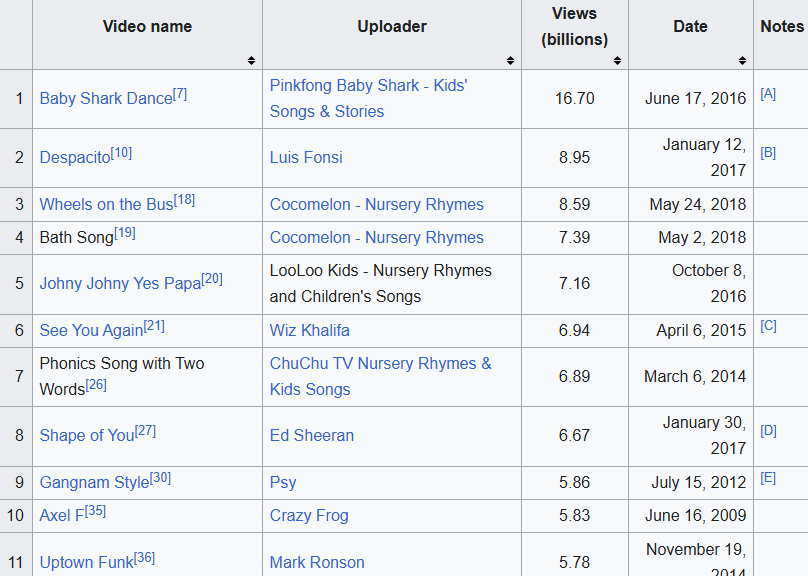

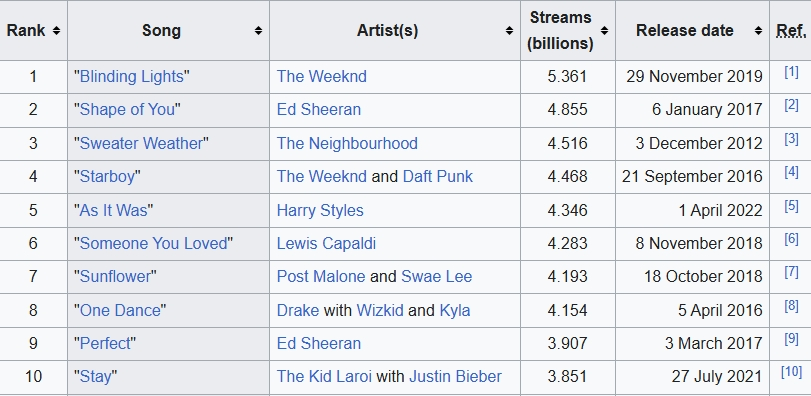

#### 1. Import Tables from Wikipedia

The data was accessed directly from publicly available Wikipedia pages using Python. The pandas.read_html() function was used to extract tables from the HTML of each webpage. Because the data is publicly available and the code uses direct URLs, the process can be repeated by anybody using the same code.

I retrieved the HTML using the requests library because the direct request to the site gave me an error. This let me succesfully download the html. After this I selected the tables containing song title, artist, and streams or views to be used.

In [4]:
import pandas as pd
import requests

headers = {"User-Agent": "Mozilla/5.0"}

spotify_html = requests.get(spotify_url, headers=headers).text
youtube_html = requests.get(youtube_url, headers=headers).text

spotify_tables = pd.read_html(spotify_html)
youtube_tables = pd.read_html(youtube_html)

/tmp/ipykernel_2641/1493116194.py:9: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  spotify_tables = pd.read_html(spotify_html)
/tmp/ipykernel_2641/1493116194.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  youtube_tables = pd.read_html(youtube_html)


#### 2. Find Tables

In [ ]:
for i, table in enumerate(spotify_tables):
    print(i)
    print(table.head(), "\n")

In [ ]:
for i, table in enumerate(youtube_tables):
    print(i)
    print(table.head(), "\n")

#### 3. Cleaning and Renaming Columns

In [16]:
spotify = spotify_tables[0]
youtube = youtube_tables[0]

In [20]:
spotify.columns = (
    spotify.columns
    .str.lower()
    .str.replace(r"\(.*\)", "", regex=True)
    .str.replace(" ", "_")
    .str.strip()
)
print(spotify.columns)

Index(['song', 'artist', 'streams', 'platform'], dtype='object')


In [23]:
spotify = spotify[['song', 'artist', 'streams']]
spotify = spotify.rename(columns={'streams': 'streams'})
spotify['platform'] = 'Spotify'

In [19]:
youtube.columns = (
    youtube.columns
    .str.lower()
    .str.replace(r"\(.*\)", "", regex=True)
    .str.replace(" ", "_")
    .str.strip()
)
print(youtube.columns)

Index(['video_name', 'uploader', 'views_', 'date', 'notes', 'unnamed:_5'], dtype='object')


In [24]:
youtube = youtube[['video_name', 'uploader', 'views_']]
youtube = youtube.rename(columns={
    'video_name': 'song',
    'uploader': 'artist',
    'views_': 'streams'
})
youtube['platform'] = 'YouTube'

In [45]:
youtube = youtube[youtube['song'] != "Baby Shark Dance"]

Column names were cleaned up by removing spaces, parentheses, and inconsistent formatting. I cleaned these by converting to lowercase, removing extra text, and replacing spaces with underscores.

The Spotify and YouTube datasets used different column names (“artist” and “uploader”, “streams” and “views”), so columns were renamed so they would merge.

Invalid rows were removed and non music videos were removed.

#### 4. Convert to Numbers
Data that wasn't numeric was removed by using pd.to(numeric)

In [46]:
spotify['streams'] = pd.to_numeric(
    spotify['streams'],
    errors='coerce'
)

youtube['streams'] = pd.to_numeric(
    youtube['streams'],
    errors='coerce'
)
youtube['platform'] = 'YouTube'

spotify = spotify.dropna(subset=['streams'])
youtube = youtube.dropna(subset=['streams'])

#### 5. Combine Data!

In [47]:
df = pd.concat([spotify, youtube], ignore_index=True)
df = df.sort_values(by='streams', ascending=False)

#### Final Top 20 Table
Most of them are YouTube

In [50]:
df_final = df[['song', 'artist', 'streams', 'platform']] \
    .sort_values(by='streams', ascending=False)

df_final.reset_index(drop=True).head(20)

,song,artist,streams,platform
0,Despacito[10],Luis Fonsi,8.950,YouTube
1,Wheels on the Bus[18],Cocomelon - Nursery Rhymes,8.590,YouTube
2,Bath Song[19],Cocomelon - Nursery Rhymes,7.390,YouTube
3,Johny Johny Yes Papa[20],LooLoo Kids - Nursery Rhymes and Children's Songs,7.160,YouTube
4,See You Again[21],Wiz Khalifa,6.940,YouTube
5,Phonics Song with Two Words[26],ChuChu TV Nursery Rhymes & Kids Songs,6.890,YouTube
6,Shape of You[27],Ed Sheeran,6.670,YouTube
7,Gangnam Style[30],Psy,5.860,YouTube
8,Axel F[35],Crazy Frog,5.830,YouTube
9,Uptown Funk[36],Mark Ronson,5.780,YouTube


When compared with the websites, the placements on this table are accurate.

Possible limitations: The sources are updated over time, so there could be a time where the code is run and results change.

Spotify and YouTube use different ways of measuring engagement so they aren't perfectly comparable.

YouTube adds a lot of songs and nursery rhymes that I would rather not be on there but I don't wish to redo all my work.

#### Conclusion

In this project, I combined data from Wikipedia pages for Spotify and YouTube to create a single dataset comparing song popularity across platforms. The final dataset lets me rank songs using both streams and views.

There are some limitations in the data. Spotify streams and YouTube views aren't the exact same thing, so the comparison isn't perfectly equal. A few messy or missing values were also cleaned or removed during processing.
Overall, even with these issues, the dataset still gives a good general idea of which songs are most popular across both platforms.